In [1]:
import numpy as np
import pandas as pd
from scipy import stats
df=pd.read_csv("train-selected-columns.csv")
avg_age=df['Age'].mean()
print(avg_age)
print(df.fillna({'Age':avg_age},inplace=True))
print(df.isnull().sum())


29.69911764705882
None
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
dtype: int64


In [2]:
#smoothing
x=pd.cut(df['Age'],bins=[0,18,35,50,65,80],labels=['0-18','18-35','35-50','50-65','65-80'])
print(x.value_counts())
#binning
x_p=pd.qcut(df['Age'],q=3,labels=['0-20%','21-40%','41-60%'])
print(x_p.value_counts())


Age
18-35    535
35-50    153
0-18     139
50-65     56
65-80      8
Name: count, dtype: int64
Age
21-40%    304
0-20%     301
41-60%    286
Name: count, dtype: int64


In [3]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
iqr_outliers_mask = (df['Age'] < lower_bound) | (df['Age'] > upper_bound)
iqr_outlier_count = iqr_outliers_mask.sum()
print(f"Total outliers detected using IQR: {iqr_outlier_count}")

Total outliers detected using IQR: 66


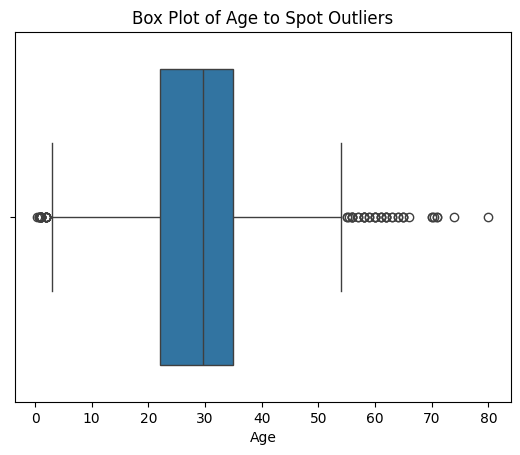

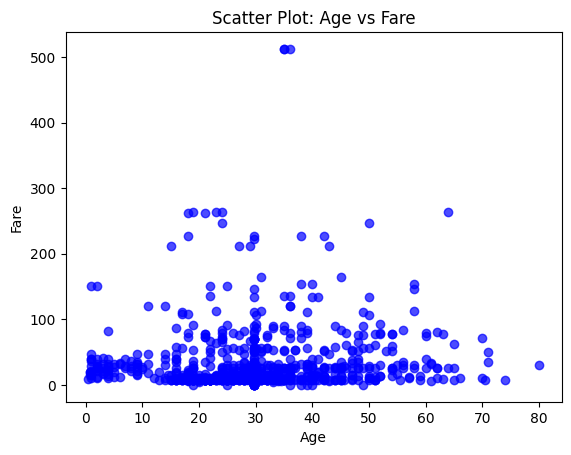

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
# Method A: Using Seaborn (Cleaner look)
sns.boxplot(x=df['Age'])
plt.title('Box Plot of Age to Spot Outliers')
plt.show()
# Scatter plot comparing Age vs. Fare
plt.scatter(df['Age'], df['Fare'], color='blue', alpha=0.7)

# Adding labels and title
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Scatter Plot: Age vs Fare')

# Display the plot
plt.show()


In [17]:
import pandas as pd

# Skip the faulty lines entirely
df1 = pd.read_csv("adult_names.csv", on_bad_lines='skip')
df2 = pd.read_csv("old_adult_names.csv", on_bad_lines='skip')

# Now your original duplicate checks will run perfectly:
print("df1 Duplicates Found:", df1.duplicated().sum())
df1_cleaned = df1.drop_duplicates()

print("df2 Duplicates Found:", df2.duplicated().sum())
df2_cleaned = df2.drop_duplicates()


df1 Duplicates Found: 12
df2 Duplicates Found: 0


In [24]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Define the Adult dataset columns
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 
    'marital-status', 'occupation', 'relationship', 'race', 'sex', 
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'fare'
]

# Load datasets safely ignoring text comments at the top
df1 = pd.read_csv("adult_names.csv", names=columns, header=None, comment='|', on_bad_lines='skip')
df2 = pd.read_csv("old_adult_names.csv", names=columns, header=None, comment='|', on_bad_lines='skip')

# --- DATA INTEGRATION ---
# Stack df1 and df2 into a single unified DataFrame
combined_df = pd.concat([df1, df2], ignore_index=True)
print(f"Shape after Integration: {combined_df.shape}")

Shape after Integration: (88, 15)


In [25]:
# Join horizontally using the dataframe indexes
# Suffixes are required since both dataframes share column names
joined_df = df1.join(df2, lsuffix='_left', rsuffix='_right')
print("Join shape:", joined_df.shape)
print(joined_df[['age_left', 'age_right', 'fare_left', 'fare_right']].head())

Join shape: (13, 30)
                     age_left  \
0                        >50K   
1            age: continuous.   
2          workclass: Private   
3         fnlwgt: continuous.   
4  education-num: continuous.   

                                           age_right  fare_left  fare_right  
0                        1. Title of Database: adult        NaN         NaN  
1                                        2. Sources:        NaN         NaN  
2     (a) Original owners of database (name/phone...        NaN         NaN  
3                                  US Census Bureau.        NaN         NaN  
4     (b) Donor of database (name/phone/snail add...        NaN         NaN  


In [26]:
# Check how many duplicate rows exist across the entire merged DataFrame
print("Total duplicate rows:", combined_df.duplicated().sum())

# If you only want to check for duplicates based on specific columns
print("Duplicates based on Age & Fare:", combined_df.duplicated(subset=['age', 'fare']).sum())

Total duplicate rows: 12
Duplicates based on Age & Fare: 12


In [27]:
# Drop exact duplicate rows entirely
cleaned_df = combined_df.drop_duplicates()

# Reset index since rows were deleted
cleaned_df = cleaned_df.reset_index(drop=True)

print("Shape after removing duplicates:", cleaned_df.shape)

Shape after removing duplicates: (76, 15)


In [30]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. Define the 15 standard schema columns
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 
    'marital-status', 'occupation', 'relationship', 'race', 'sex', 
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# 2. Load the datasets safely ignoring comments (lines starting with '|')
df1 = pd.read_csv("adult_names.csv", names=columns, header=None, comment='|', on_bad_lines='skip')
df2 = pd.read_csv("old_adult_names.csv", names=columns, header=None, comment='|', on_bad_lines='skip')

# 3. Data Integration: Combine both dataframes vertically
combined_df = pd.concat([df1, df2], ignore_index=True)

# 4. Duplicate Records: Check and remove redundancies
print("Total duplicate rows found:", combined_df.duplicated().sum())
cleaned_df = combined_df.drop_duplicates().reset_index(drop=True)

# 5. Automatically isolate ONLY the numerical columns
# This completely bypasses 'income' text values like '>50K'
numeric_cols = cleaned_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("\nAutomatically detected numerical columns for scaling:", numeric_cols)

# 6. Data Transformation: Initialize and apply MinMaxScaler safely
min_max_scaler = MinMaxScaler()
norm_df = cleaned_df.copy()

norm_df[numeric_cols] = min_max_scaler.fit_transform(cleaned_df[numeric_cols])

print("\n--- Data Integration & Normalization Successful! ---")
# Displaying 'age' and whatever numeric column represents your numerical target
print(norm_df[numeric_cols].head())

Total duplicate rows found: 12

Automatically detected numerical columns for scaling: ['income']

--- Data Integration & Normalization Successful! ---
   income
0     NaN
1     NaN
2     NaN
3     NaN
4     NaN


c:\Users\sures\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
c:\Users\sures\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


In [31]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Define the 15 standard schema columns
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 
    'marital-status', 'occupation', 'relationship', 'race', 'sex', 
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# 2. Load the datasets safely ignoring comments (lines starting with '|')
df1 = pd.read_csv("adult_names.csv", names=columns, header=None, comment='|', on_bad_lines='skip')
df2 = pd.read_csv("old_adult_names.csv", names=columns, header=None, comment='|', on_bad_lines='skip')

# 3. Data Integration: Combine both dataframes vertically
combined_df = pd.concat([df1, df2], ignore_index=True)

# 4. Duplicate Records: Check and remove redundancies
cleaned_df = combined_df.drop_duplicates().reset_index(drop=True)

# 5. Automatically isolate ONLY the numerical columns
# This completely avoids text values like '>50K'
numeric_cols = cleaned_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical columns selected for standardization:", numeric_cols)

# 6. Data Transformation: Initialize and apply StandardScaler safely
std_scaler = StandardScaler()
std_df = cleaned_df.copy()

std_df[numeric_cols] = std_scaler.fit_transform(cleaned_df[numeric_cols])

print("\n--- Data Integration & Standardization Successful! ---")
print(std_df[numeric_cols].head())


Numerical columns selected for standardization: ['income']

--- Data Integration & Standardization Successful! ---
   income
0     NaN
1     NaN
2     NaN
3     NaN
4     NaN


c:\Users\sures\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\sures\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\sures\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [35]:
import pandas as pd

# 1. Standard 15 columns for the Adult dataset
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 
    'marital-status', 'occupation', 'relationship', 'race', 'sex', 
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# 2. Load the datasets safely (ignoring comments)
df1 = pd.read_csv("adult_names.csv", names=columns, header=None, comment='|', on_bad_lines='skip')
df2 = pd.read_csv("old_adult_names.csv", names=columns, header=None, comment='|', on_bad_lines='skip')

# 3. Combine datasets and clean strings (removing accidental leading/trailing spaces)
combined_df = pd.concat([df1, df2], ignore_index=True)
cleaned_df = combined_df.drop_duplicates().reset_index(drop=True)

# Clean text columns to make sure 'sex' doesn't contain weird data offsets
for col in cleaned_df.select_dtypes(include=['object']).columns:
    cleaned_df[col] = cleaned_df[col].astype(str).str.strip()

# 4. Corrected Groupby
# Setting numeric_only=True tells pandas to ignore text strings completely!
grouped_by_sex = cleaned_df.groupby('sex').mean(numeric_only=True)

print("--- Average Values by Sex ---")
print(grouped_by_sex)


--- Average Values by Sex ---
                 income
sex                    
Farming-fishing     NaN
nan                 NaN


In [42]:
# --- RESAMPLE AGGREGATION ---
resample_df = cleaned_df.copy()

# 1. Create a dummy date range matching the number of rows in your dataframe
resample_df['date'] = pd.date_range(start='2026-01-01', periods=len(resample_df), freq='H')

# 2. Set the date column as the index (required for .resample())
resample_df = resample_df.set_index('date')

# 3. Resample the data by Day ('D') or Month ('M') and take the mean of numerical metrics
daily_averages = resample_df[numeric_cols].resample('D').mean()

print("\n--- Daily Resampled Averages Preview ---")
print(daily_averages.head())




--- Daily Resampled Averages Preview ---
            age  fnlwgt  education-num  capital-gain  capital-loss  \
date                                                                 
2026-01-01  NaN     NaN            NaN           NaN           NaN   

            hours-per-week  
date                        
2026-01-01             NaN  


C:\Users\sures\AppData\Local\Temp\ipykernel_12304\3007978183.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  resample_df['date'] = pd.date_range(start='2026-01-01', periods=len(resample_df), freq='H')


In [41]:
import pandas as pd

# 1. Define the correct 15 columns for the Adult dataset
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 
    'marital-status', 'occupation', 'relationship', 'race', 'sex', 
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# 2. Load the datasets safely
df1 = pd.read_csv("adult_names.csv", names=columns, header=None, comment='|', on_bad_lines='skip')
df2 = pd.read_csv("old_adult_names.csv", names=columns, header=None, comment='|', on_bad_lines='skip')

# Combine them 
combined_df = pd.concat([df1, df2], ignore_index=True)

# 3. CRITICAL FIX: Strip spaces and remove structural header rows leaking into data
for col in combined_df.select_dtypes(include=['object']).columns:
    combined_df[col] = combined_df[col].astype(str).str.strip()

# Drop any row where columns contain structural metadata text like "occupation:"
cleaned_df = combined_df[~combined_df['workclass'].str.contains(':', na=False)].copy()

# 4. Make sure numeric columns are recognized as actual numbers
numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
for col in numeric_cols:
    cleaned_df[col] = pd.to_numeric(cleaned_df[col], errors='coerce')

# Drop true duplicates
cleaned_df = cleaned_df.drop_duplicates().dropna(subset=['sex']).reset_index(drop=True)

# 5. Safe Groupby
# numeric_only=True completely isolates numbers and stops string errors
grouped_by_sex = cleaned_df.groupby('sex').mean(numeric_only=True)

print("--- Cleaned Average Values Grouped by Sex ---")
print(grouped_by_sex)

--- Cleaned Average Values Grouped by Sex ---
                 age  fnlwgt  education-num  capital-gain  capital-loss  \
sex                                                                       
Farming-fishing  NaN     NaN            NaN           NaN           NaN   
nan              NaN     NaN            NaN           NaN           NaN   

                 hours-per-week  income  
sex                                      
Farming-fishing             NaN     NaN  
nan                         NaN     NaN  


In [43]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. Define the correct 15 columns for the Adult dataset
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 
    'marital-status', 'occupation', 'relationship', 'race', 'sex', 
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# 2. Load and merge datasets safely
df1 = pd.read_csv("adult_names.csv", names=columns, header=None, comment='|', on_bad_lines='skip')
df2 = pd.read_csv("old_adult_names.csv", names=columns, header=None, comment='|', on_bad_lines='skip')
combined_df = pd.concat([df1, df2], ignore_index=True)

# 3. Clean trailing/leading whitespaces from text data
for col in combined_df.select_dtypes(include=['object']).columns:
    combined_df[col] = combined_df[col].astype(str).str.strip()

# 4. Remove leaky metadata/header rows if they exist
cleaned_df = combined_df[~combined_df['workclass'].str.contains(':', na=False)].copy()
cleaned_df = cleaned_df.drop_duplicates().reset_index(drop=True)

# 5. Initialize the LabelEncoder
label_encoder = LabelEncoder()
encoded_df = cleaned_df.copy()

# 6. Apply LabelEncoder to categorical targets (e.g., 'sex' and 'income')
encoded_df['sex_encoded'] = label_encoder.fit_transform(cleaned_df['sex'])
encoded_df['income_encoded'] = label_encoder.fit_transform(cleaned_df['income'])

print("--- Categorical Label Encoding Successful! ---")
print(encoded_df[['sex', 'sex_encoded', 'income', 'income_encoded']].head())

--- Categorical Label Encoding Successful! ---
   sex  sex_encoded  income  income_encoded
0  nan            1     NaN               0
1  nan            1     NaN               0
2  nan            1     NaN               0
3  nan            1     NaN               0
4  nan            1     NaN               0


In [51]:
import pandas as pd

# 1. Define the correct 15 columns for the Adult dataset
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 
    'marital-status', 'occupation', 'relationship', 'race', 'sex', 
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# 2. Load the dataset safely (using only the true data file to avoid documentation row pollution)
cleaned_df = pd.read_csv("old_adult_names.csv", names=columns, header=None, comment='|', on_bad_lines='skip')

# 3. Clean string features and discard any lingering space gaps
for col in cleaned_df.select_dtypes(include=['object']).columns:
    cleaned_df[col] = cleaned_df[col].astype(str).str.strip()

# 4. Pick a subset of categorical features to encode to keep the display clean
categorical_cols_to_encode = ['sex', 'income']

# 5. Apply One-Hot Encoding
# drop_first=True reduces multi-collinearity (e.g., sex_Male=1 implies Female=0)
encoded_df = pd.get_dummies(cleaned_df, columns=categorical_cols_to_encode, drop_first=True)

# 6. View the newly created binary columns
new_binary_cols = [col for col in encoded_df.columns if col not in columns]
print("--- One-Hot Encoding (get_dummies) Successful! ---")
print(f"Generated Binary Columns: {new_binary_cols}\n")
print(encoded_df[new_binary_cols].head())

--- One-Hot Encoding (get_dummies) Successful! ---
Generated Binary Columns: ['sex_nan']

   sex_nan
0     True
1     True
2     True
3     True
4     True
